# Box plots of time series features

In [49]:
import numpy as np
import os
import pandas as pd
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
plt.style.use("my_style.mplstyle")

Duplicate key in file 'my_style.mplstyle', line 25 ('text.usetex: False')
Duplicate key in file 'my_style.mplstyle', line 26 ('font.family: sans-serif')
Duplicate key in file 'my_style.mplstyle', line 27 ('font.sans-serif: Helvetica')


In [51]:
models=['GNO', 'UNO', 'PINK', 'BROWN', 'VIOLET', # noises (R)
        'AR1_GNO', 'STAR_GNO', #    ARMA (R)
        'ARNOLD', 'CHIRIKOV', 
        'OU', 'Oscillator',# Conservative chaotic maps (R)
        'BRW_cont', 
        'HENR_diverse', 'HENR_same', 'QUADRATIC_RSUM', # Sum of frwd and bckwd realisations of chaotic maps (R)
        'AR1_UNO', 'ARMA11_UNO', 'AR3_Gamma', 'N_AR2', 'SETAR1_GNO', 'SETAR2_GNO',
        'HEN', 'HEN_SUM', 'LOGISTIC4', 'LOGISTIC38284', 'QUADRATIC', # Chaotic maps (I)
        'MODA', 'LLOG', # Other deterministic (I)
        'SINE_STOCH', # Other stochastic (I)
        'LORENZ_SUM', 'ROSSLER_SUM', 
        'MACKEYGLASS17', 'VDP', 
        'LORENZ_STOCH_SUM',
        'VDP_STOCH'
        ]

print('Models:', models)

model_keywords={ # discrete
                'GNO': 'reversible', 'UNO': 'reversible', 'PINK': 'reversible', 'BROWN': 'reversible', 'VIOLET': 'reversible',
                'AR1_GNO': 'reversible', 'STAR_GNO': 'reversible',
                'ARNOLD': 'reversible', 'CHIRIKOV': 'reversible',
                'HENR_diverse': 'reversible', 'HENR_same': 'reversible', 'QUADRATIC_RSUM': 'reversible',
                'AR1_UNO': 'irreversible', 'ARMA11_UNO': 'irreversible', 'AR3_Gamma': 'irreversible', 'N_AR2': 'irreversible', 'SETAR1_GNO': 'irreversible', 'SETAR2_GNO': 'irreversible', 
                'HEN': 'irreversible', 'HEN_SUM': 'irreversible', 'LOGISTIC4': 'irreversible', 'LOGISTIC38284': 'irreversible','QUADRATIC': 'irreversible',
                'MODA': 'irreversible', 'LLOG': 'irreversible',
                'SINE_STOCH': 'irreversible',
                # continuous
                'BRW_cont': 'reversible', 'OU': 'reversible', 'Oscillator': 'reversible',
                'LORENZ_SUM': 'irreversible', 'ROSSLER_SUM': 'irreversible',
                'MACKEYGLASS17': 'irreversible', 'VDP': 'irreversible',
                'LORENZ_STOCH_SUM': 'irreversible',
                'VDP_STOCH': 'irreversible'
        }

# Idea: put together discrete and continuou models with same caratteristics 
# category models = { iid noise, arma, chaos, sum chaos, other deterministic, other stochastic}
cathegory_models = {
    'GNO': 'iid noise', 'UNO': 'iid noise', 'PINK': 'iid noise', 'BROWN': 'iid noise', 'VIOLET': 'iid noise',   
        'AR1_GNO': 'ARMA', 'STAR_GNO': 'ARMA', 'AR1_UNO': 'ARMA', 'ARMA11_UNO': 'ARMA', 'AR3_Gamma': 'ARMA', 'N_AR2': 'ARMA', 'SETAR1_GNO': 'ARMA', 'SETAR2_GNO': 'ARMA',
        'ARNOLD': 'chaos', 'CHIRIKOV': 'chaos', 'HEN': 'chaos',  'LOGISTIC4': 'chaos', 'LOGISTIC38284': 'chaos', 'QUADRATIC': 'chaos',  
        'HENR_diverse': 'sum chaos', 'HENR_same': 'sum chaos',  'QUADRATIC_RSUM': 'sum chaos', 'HEN_SUM': 'sum chaos', 'LORENZ_SUM': 'sum chaos', 'ROSSLER_SUM': 'sum chaos',
        'MODA': 'other deterministic', 'LLOG': 'other deterministic', 'MACKEYGLASS17': 'other deterministic', 'VDP': 'other deterministic', 'Oscillator': 'other deterministic',
        'SINE_STOCH': 'other stochastic', 'OU': 'other stochastic', 'BRW_cont': 'other stochastic','LORENZ_STOCH_SUM': 'other stochastic','VDP_STOCH': 'other stochastic'
}

Models: ['GNO', 'UNO', 'PINK', 'BROWN', 'VIOLET', 'AR1_GNO', 'STAR_GNO', 'ARNOLD', 'CHIRIKOV', 'OU', 'Oscillator', 'BRW_cont', 'HENR_diverse', 'HENR_same', 'QUADRATIC_RSUM', 'AR1_UNO', 'ARMA11_UNO', 'AR3_Gamma', 'N_AR2', 'SETAR1_GNO', 'SETAR2_GNO', 'HEN', 'HEN_SUM', 'LOGISTIC4', 'LOGISTIC38284', 'QUADRATIC', 'MODA', 'LLOG', 'SINE_STOCH', 'LORENZ_SUM', 'ROSSLER_SUM', 'MACKEYGLASS17', 'VDP', 'LORENZ_STOCH_SUM', 'VDP_STOCH']


In [52]:
cwd = os.getcwd()

dir_hctsa= cwd+'/data-analysis/'
dir_accuracy= cwd+'/data-analysis/accuracy/'
dir_zero=cwd+'/data-zero/'
dir_figures=cwd+'/data-analysis/figures/'

In [53]:
# LOAD IF I WANT THE ACCURACY ON THE FULL SET OF OPERATIONS AND DATASET
# load accuracy 1NN
df_ops_full = pd.read_csv(dir_accuracy+'df_accuracy_abs_1NN.csv')

# Load full hctsa matrix
df_full_hctsa=pd.read_csv(dir_hctsa+'df_TS_DataMat_diff.csv')
df_full_hctsa.set_index(['Model'], inplace=True)

# Add column with reversible/irreversible label
df_type=df_full_hctsa.index.get_level_values(0).map(model_keywords)
df_full_hctsa.insert(0,'Type',df_type)

# ABSOLUTE VALUE
numeric_cols = df_full_hctsa.select_dtypes(include=[np.number]).columns
df_full_hctsa[numeric_cols] = df_full_hctsa[numeric_cols].abs()

# Select rows with model in model
df_full_hctsa = df_full_hctsa[df_full_hctsa.index.get_level_values(0).isin(models)]

/var/folders/wz/jq7_490s6t1dh9vzst6cqgdc0000gp/T/ipykernel_63707/2206717408.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_full_hctsa.insert(0,'Type',df_type)


In [54]:
# Load good performing features
df_ops_good = pd.read_csv(dir_accuracy+'df_accuracy_good_1NN.csv')

# Load ops zero
df_ops_zero = pd.read_csv(dir_zero+'df_ops_zero.csv')

# Check what good features are among the zero ones
common_values = pd.merge(df_ops_good, df_ops_zero, left_on='Operation', right_on='Name', how='inner')
# Display the common values
print(common_values)


Empty DataFrame
Columns: [Operation, Accuracy, Name, Value]
Index: []


In [55]:
# Load only features that are not zero
df_ops_good = df_ops_good[~df_ops_good['Operation'].isin(df_ops_zero['Name'])]
df_good_hctsa = pd.read_csv(dir_accuracy+'df_good_hctsa_1NN.csv')
df_good_hctsa.set_index('Model', inplace=True)

# ABSOLUTE VALUE
numeric_cols = df_good_hctsa.select_dtypes(include=[np.number]).columns
df_good_hctsa[numeric_cols] = df_good_hctsa[numeric_cols].abs()

# Select rows with model in model
df_good_hctsa = df_good_hctsa[df_good_hctsa.index.get_level_values(0).isin(models)]



In [56]:
# Add column of model categories
df_category = df_good_hctsa.index.get_level_values(0).map(cathegory_models)
df_good_hctsa.insert(0, 'Category', df_category)

In [57]:
def plot_single_box_plot(df, op):
    palette_c = ["#e96196",
                "#6dbe59",
                "#b07de2",
                "#c2ad39",
                "#568eff",
                "#e57548"]
    
    palette_c_alpha = [
         "#ffb3c9",  # light bright pink
    "#b6f7a4",  # light bright green
    "#dab7f8",  # light bright purple
    "#f7e779",  # light bright yellow
    "#b7ccff",  # light bright blue
    "#ffc199"   # light bright orange
    ]

    palette_t = ['#2c5b93', '#f44d4d']
 
    category = df['Category'].unique()
    type = df['Type'].unique()
    
    # Ensure the color palette length matches the number of unique classes
    category_palette = dict(zip(category, palette_c))
    category_palette_alpha = dict(zip(category, palette_c))
    type_palette = dict(zip(type, palette_t))
    
    # Violin plot of Accuracy by Feature and Class
    plt.figure(figsize=(6, 5)) #(6,5)
    ax = sns.boxplot(x='Type', y=op, data=df, hue='Type',
                        dodge=False, palette = type_palette, linewidth=2, width=0.1)  
                        

    # Find the maximum and minimum in the reversible groups
    max_reversible = df[df['Type'] == 'reversible'][op].max()
    min_reversible = df[df['Type'] == 'reversible'][op].min()

    # Draw horizontal lines at these values
    ax.axhline(max_reversible, color='gray', linestyle='--', linewidth=2, label='Max R', zorder=0)
    ax.axhline(min_reversible, color='gray', linestyle='--', linewidth=2, label='Min I', zorder=0)

    # Separate points of irreversible if they are within [min,max] of reversible and outside [min,max] of irreversible
    df_alpha= df[(df['Type'] == 'irreversible') &
                          (df[op] >= min_reversible) & (df[op] <= max_reversible)]
    
    df_others = df[(df['Type'] == 'irreversible') &
                          ((df[op] < min_reversible) | (df[op] > max_reversible))]
    
    df_rev = df[df['Type'] == 'reversible']
    
    old_len_collections = len(ax.collections)
    # Overlay stripplot for jittered individual points
    df_subset_alpha = df_alpha.iloc[::14, :]
    df_subset_others = df_others.iloc[::18, :]
    df_subset_rev = df_rev.iloc[::18, :]


    sns.stripplot(x='Type', y=op, data=df_subset_rev, hue='Category', palette=category_palette,
                  dodge=False, ax=ax, alpha=1, linewidth=0.15, edgecolor='white', jitter=True, marker = 'o', size=8)
                  
    sns.stripplot(x='Type', y=op, data=df_subset_alpha, hue='Category', palette=category_palette_alpha, 
                  dodge=False, ax=ax, alpha=1, linewidth=0.15, edgecolor='white', jitter=True, marker = 'o', size=8)
    sns.stripplot(x='Type', y=op, data=df_subset_others, hue='Category', palette=category_palette, 
                  dodge=False, ax=ax, alpha=1, linewidth=0.15, edgecolor='white', jitter=True, marker = 'o', size=8
                  )


    # Adjust the x-offset of the points to avoid overlap
    for dots in ax.collections[old_len_collections:]:
        dots.set_offsets(dots.get_offsets() + np.array([0.22, 0]))
    
    # change x-ticks to be ['r' and 'i]
    ax.set_xticklabels(['R', 'I'], fontsize=34)
    # Rotate x-ticks
    #plt.xticks(rotation=45, ha='right')
    # Set labels and title
    ax.set_xlabel('')
    ax.set_ylabel(r'$|\text{MAE AR(2) predictor}|$')
    ax.set_title(r'MAE AR(2) of predictor')
    
    # Remove redundant legends
    handles, labels = ax.get_legend_handles_labels()
    if len(handles) > 0:
        ax.legend_.remove()
    # Set legend with color classes
    legend_labels = [plt.Line2D([0], [0], marker='s', color='w', label=label, 
                                  markerfacecolor=color, markersize=15) for label, color in category_palette.items()]
    # Put legend outside the plot
    #ax.legend(handles=legend_labels, title='Family of processes', loc='upper left', bbox_to_anchor=(1, 1), fontsize=24, title_fontsize=24)

    ax.axhline(0, color='black', linestyle='-', linewidth=2, zorder=0)

    
 
    # SAVE FIGURE svg
    plt.savefig(dir_figures+op+'_box_plot_h.svg', format='svg', bbox_inches='tight')
    plt.tight_layout()
    plt.show()

/var/folders/wz/jq7_490s6t1dh9vzst6cqgdc0000gp/T/ipykernel_63707/1617437093.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['R', 'I'], fontsize=34)


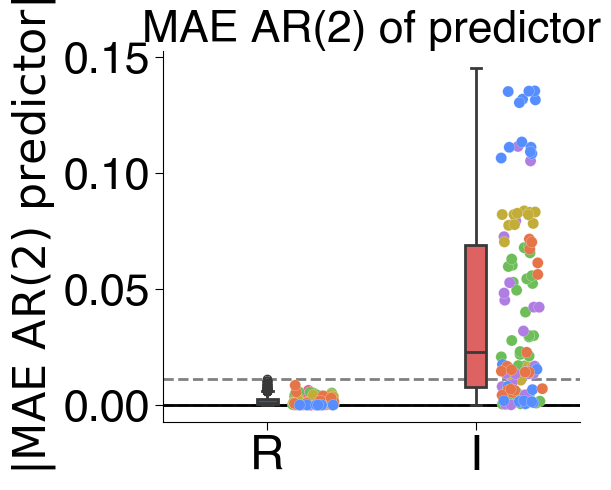

In [58]:
op = 'MF_steps_ahead_ar_2_6_mabserr_1'

#SB_MotifTwo_diff_uu
#AC_nl_001
# MF_steps_ahead_ar_2_6_mabserr_1



plot_single_box_plot(df_good_hctsa, op)

In [113]:
def plot_op_process(df, pr1, pr2, op):
    fig = plt.figure(figsize=(7, 8))
    df_pr1 = df[df.index.get_level_values(0) == pr1]
    df_pr2 = df[df.index.get_level_values(0) == pr2]
    df_rev = df[df['Type'] == 'reversible']

    # Max and min values for reversible processes
    max_rev = df_rev[op].max()
    min_rev = df_rev[op].min()

    df_plot = pd.concat([df_pr1, df_pr2], axis=0)
    df_plot.reset_index(inplace=True)
    df_rev = df_rev.iloc[::12, :]
        # Overlay stripplot for jittered individual points
    df_subset = df_plot.iloc[::5, :]
    ax = sns.boxplot(x='Type', y=op, data=df_rev, hue='Type',
                        dodge=False, palette = ['#2c5b93'], 
                        linewidth=1.5, width=0.9)
    
    sns.stripplot(x='Type', y=op, data=df_rev, hue='Type', 
                          dodge=False, ax=ax, alpha=0.6, linewidth=0.3, edgecolor='white', jitter=True, marker = 'o', size=10,
                          palette=['black'])
    for dots in ax.collections[len(ax.collections)//2:]:
        dots.set_offsets(dots.get_offsets() + np.array([0.22, 0]))
    sns.boxplot(x='Model', y=op, data=df_plot, hue='Model',
                        dodge=False, palette = ['#f44d4d', '#f44d4d'], 
                        linewidth=1.5, width=0.9)
    

    sns.stripplot(x='Model', y=op, data=df_subset, hue='Model', 
                  dodge=False, ax=ax, alpha=0.8, linewidth=0.3, edgecolor='white', jitter=True, marker = 'o', size=10, palette=['#6dbe59', '#b07de2']) 
    # Adjust the x-offset of the points to avoid overlap
    for dots in ax.collections[len(ax.collections)//2:]:
        dots.set_offsets(dots.get_offsets() + np.array([0.22, 0]))

    
    plt.xticks(rotation=45, ha='right')
    # Set labels and title

    ax.set_xlabel(r'Processes')
    ax.set_ylabel(r'$|\Delta p_{\text{uu}}(\boldsymbol{x})|$')

    # xticks labels
    ax.set_xticklabels(['Reversible', 'Autoreg. with \n uniform noise', 'Logistic (r=4)'], fontsize=34)

    x_start = -1
    x_end = 2.5
    # Draw min and max horizontal lines over each box
    ax.hlines(y=max_rev, xmin=x_start, xmax=x_end,
            color='black', linestyle=(0, (8, 8)), linewidth=1.5, zorder = 10)
    ax.hlines(y=min_rev, xmin=x_start, xmax=x_end,
            color='black', linestyle=(0, (8, 8)), linewidth=1.5, zorder = 10)

    plt.tight_layout()
    # Save svg
    plt.savefig(dir_figures+op+'_boxplot_ar1_log.svg', format='svg', bbox_inches='tight')
    plt.show()
    return df_plot


/var/folders/wz/jq7_490s6t1dh9vzst6cqgdc0000gp/T/ipykernel_63707/2818989976.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Reversible', 'Autoreg. with \n uniform noise', 'Logistic (r=4)'], fontsize=34)


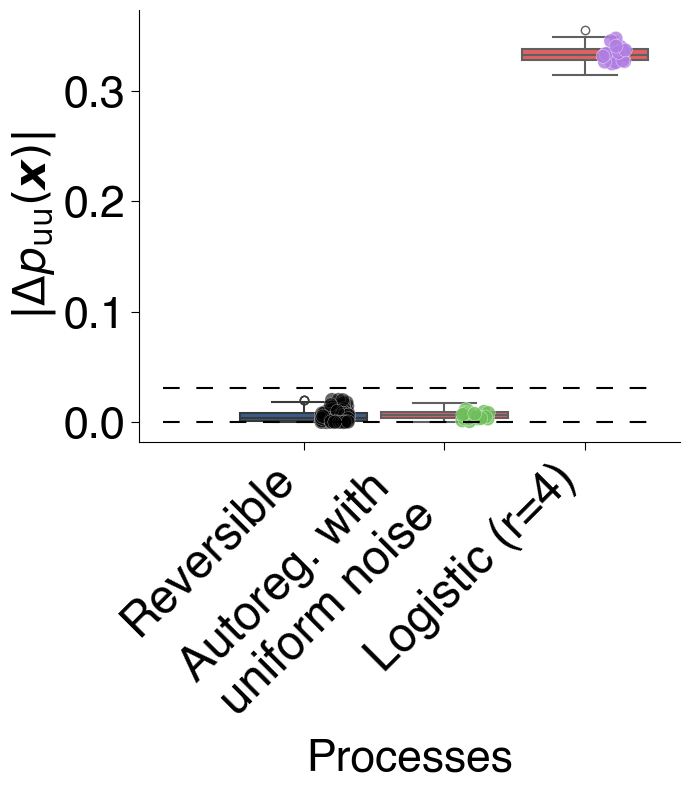

In [114]:
p1 = plot_op_process(df_good_hctsa, 'AR1_UNO', 'LOGISTIC4', 'SB_MotifTwo_diff_uu')


# Plot mean of top-performing feature absolute difference
Do it for SINE_STOCH, HEN and compare with results of reversible processes

In [70]:
df_sine_stoch = df_good_hctsa[df_good_hctsa.index.get_level_values(0) == 'SINE_STOCH']
df_henon = df_good_hctsa[df_good_hctsa.index.get_level_values(0) == 'HEN']
df_rev = df_good_hctsa[df_good_hctsa['Type'] == 'reversible']

# Mean and std per column (exclude first two columns)
df_rev_mean = df_rev.iloc[:, 2:].mean()
df_rev_std = df_rev.iloc[:, 2:].std(ddof=1)

df_sine_stoch_mean = df_sine_stoch.iloc[:, 2:].mean()
df_sine_stoch_std = df_sine_stoch.iloc[:, 2:].std(ddof=1)

df_henon_mean = df_henon.iloc[:, 2:].mean()
df_henon_std = df_henon.iloc[:, 2:].std(ddof=1)

# change type 
df_sine_stoch['Type'] = 'SINE_STOCH'
df_henon['Type'] = 'HENON'
df_rev['Type'] = 'REVERSIBLE'


/var/folders/wz/jq7_490s6t1dh9vzst6cqgdc0000gp/T/ipykernel_63707/934732940.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sine_stoch['Type'] = 'SINE_STOCH'
/var/folders/wz/jq7_490s6t1dh9vzst6cqgdc0000gp/T/ipykernel_63707/934732940.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_henon['Type'] = 'HENON'
/var/folders/wz/jq7_490s6t1dh9vzst6cqgdc0000gp/T/ipykernel_63707/934732940.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

In [71]:

# Plot mean lines
# Melt the data for plotting
df_means = pd.DataFrame({
    'Operation': df_rev_mean.index,
    'Reversible_Mean': df_rev_mean.values,
    'Reversible_Std': df_rev_std.values,
    'SINE_STOCH_Mean': df_sine_stoch_mean.values,
    'SINE_STOCH_Std': df_sine_stoch_std.values,
    'HEN_Mean': df_henon_mean.values,
    'HEN_Std': df_henon_std.values
})
df_means_melted = pd.melt(df_means, id_vars='Operation', value_vars=['Reversible_Mean', 'SINE_STOCH_Mean', 'HEN_Mean'], 
                          var_name='Type', value_name='Mean')
df_means_melted_std = pd.melt(df_means, id_vars='Operation', value_vars=['Reversible_Std', 'SINE_STOCH_Std', 'HEN_Std'], 
                          var_name='Type', value_name='Std')

# Change Type names for legend
df_means_melted['Type'] = df_means_melted['Type'].replace({'Reversible_Mean': 'REVERSIBLE', 'SINE_STOCH_Mean': 'SINE_STOCH', 'HEN_Mean': 'HENON'})
df_means_melted_std['Type'] = df_means_melted_std['Type'].replace({'Reversible_Std': 'REVERSIBLE', 'SINE_STOCH_Std': 'SINE_STOCH', 'HEN_Std': 'HENON'})


Text(0, 0.5, 'Mean $|\\Delta f|$(log scale)')

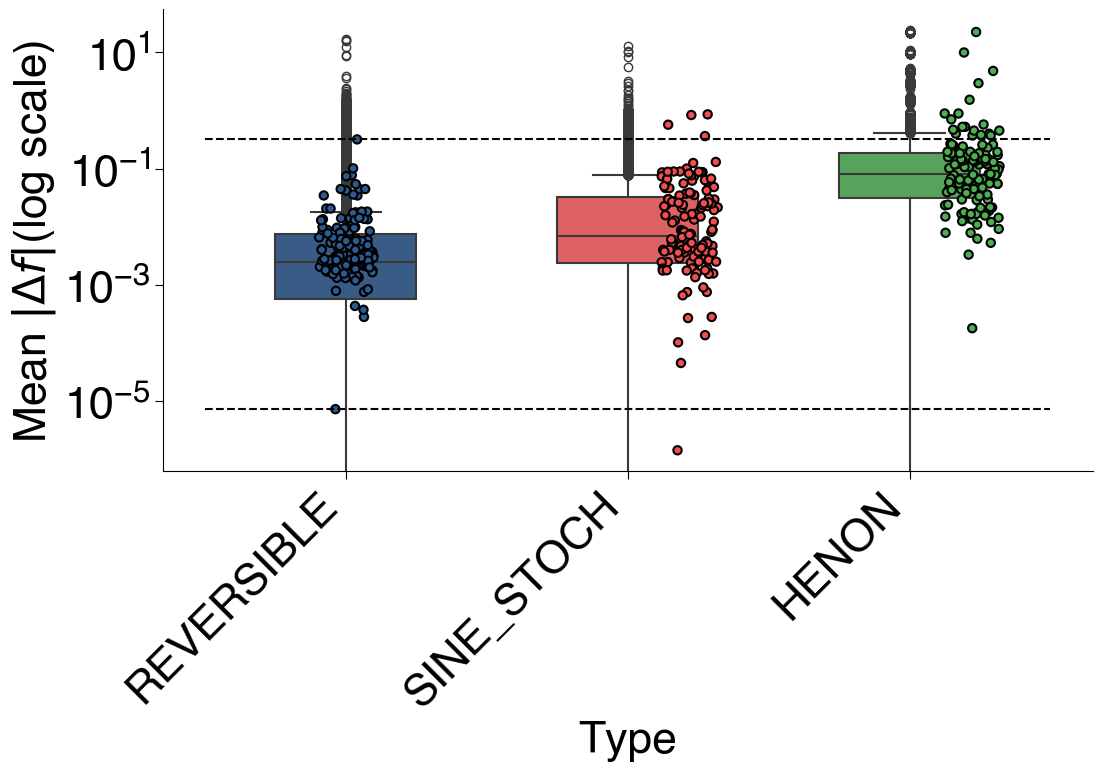

In [72]:
# Plot mean and std 
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)

#box plot of all features for reversible and SINE_STOCH
df_box = pd.concat([df_rev, df_sine_stoch, df_henon], axis=0)
df_box_reset = df_box.reset_index()
# change type

df_box_melted = pd.melt(df_box_reset, id_vars=['Model', 'Type', 'Category'], value_vars=df_box_reset.columns[3:], 
                        var_name='Operation', value_name='Value')
sns.boxplot(x='Type', y='Value', data=df_box_melted, hue='Type',
            dodge=False, palette = ['#2c5b93', '#f44d4d', '#4caf50'], 
            linewidth=1.5, width=0.5, ax=ax)

# Overlay mean scatter
sns.stripplot(x='Type', y='Mean', data=df_means_melted, hue='Type',
                  dodge=False, ax=ax, alpha=1, linewidth=1.5, edgecolor='black', jitter=True, marker='.', size=12,
                  palette=['#2c5b93', '#f44d4d', '#4caf50'])

# log scale y-axis
ax.set_yscale('log')
# Adjust the x-offset of the points to avoid overlap
for dots in ax.collections[len(ax.collections)//2:]:
    dots.set_offsets(dots.get_offsets() + np.array([0.22, 0]))

# lines in max and min of reversible means
max_rev_mean = df_rev_mean.max()
min_rev_mean = df_rev_mean.min()
ax.hlines(y=max_rev_mean, xmin=-0.5, xmax=2.5,
        color='black', linestyle='--', linewidth=1.5, zorder = 10)
ax.hlines(y=min_rev_mean, xmin=-0.5, xmax=2.5,
        color='black', linestyle='--', linewidth=1.5, zorder = 10)

# 45 degree rotation of x-ticks
plt.xticks(rotation=45, ha='right')

# ylabel
ax.set_ylabel(r'Mean $|\Delta f|$(log scale)')

# Plot irreversible divided by class for 5 features

In [98]:
# box plot for category of processes and  single operations. In the category select only type irreversible
def plot_single_category_box_irrev(df, op1, op2, op3, op4, op5, category):
    # Filter the DataFrame for the specific category
    df_category = df[df['Category'] == category]
    # consider only irreversible processes
    df_irrev = df_category[df_category['Type'] == 'irreversible']
    df_rev = df_category[df_category['Type'] == 'reversible']

    # Find the maximum and minimum in the reversible groups
    max_reversible = df_rev[[op1, op2, op3, op4, op5]].max()
    min_reversible = df_rev[[op1, op2, op3, op4, op5]].min()
    # Color palette for name of process (Model index)
    if category == 'ARMA':
        # Greens -> ARMA
        palette = ["#009f29", "#d1bd3d", "#004712", "#78cd00", "#7a7c32", "#8cda9d"]
    elif category == 'chaos':
        palette = ["#524cb1","#aa00a6","#51137b","#8423c5"]
    elif category == 'sum chaos':
        palette = ["#e1cd00", "#da6d15", "#aa8400"]
    elif category == 'other deterministic':
        palette = ["#1fb1ff", "#72f3f9", "#005195", "#008ab3"]
    elif category == 'other stochastic':
        palette = ["#ff6837", "#c5765f", "#e88400"]
        
    
    models = df_irrev.index.get_level_values(0).unique()
    # Create palette dictionary: all processes with different color
    palette = {model: color for model, color in zip(models, palette)}
    # Create a mapping of process names to colors
    process_colors = {name: color for name, color in zip(df_irrev.index.get_level_values(0).unique(), palette)}
    # Create a new column in the DataFrame for the process colors
    df_irrev['ProcessColor'] = df_irrev.index.get_level_values(0).map(process_colors)
    
    
    # Create a new DataFrame with the two operations
    df_plot = df_irrev[[op1, op2, op3, op4, op5]].reset_index()
    df_plot = pd.melt(df_plot, id_vars='Model', value_vars=[op1, op2, op3, op4, op5], var_name='Operation', value_name='Value')
    
    # Create the box plot
    plt.figure(figsize=(17, 8))
    ax = sns.boxplot(x='Operation', y='Value', data=df_plot,  color='lightgray',
                        dodge=False,  linewidth=1.5, width=0.5)
    

    # Plot one point every 5
    df_plot = df_plot.iloc[::5, :]
    
    # Overlay stripplot for jittered individual points
    sns.stripplot(x='Operation', y='Value', data=df_plot, palette=palette,
                  hue='Model', dodge=False, alpha=1, linewidth=0.35, edgecolor='white', jitter=True, size=6)
    # Map each op to its x position (0-indexed on the plot)
    op_list = [op1, op2, op3, op4, op5]
    for i, op in enumerate(op_list):
        # x positions for the horizontal line: center ± half-width (adjust as needed)
        x_start = i - 0.35
        x_end = i + 0.35
        # Draw min and max horizontal lines over each box
        ax.hlines(y=max_reversible[op], xmin=x_start, xmax=x_end,
                color='black', linestyle='--', linewidth=1.5, zorder = 10)
        ax.hlines(y=min_reversible[op], xmin=x_start, xmax=x_end,
              color='black', linestyle='--', linewidth=1.5, zorder = 10)
    
    # Remove redundant legends
    handles, labels = ax.get_legend_handles_labels()
    if len(handles) > 0:
        ax.legend_.remove()
    # Set legend with color classes
    legend_labels = [plt.Line2D([0], [0], marker='o', color='w', label=label, 
                                  markerfacecolor=color, markersize=10) for label, color in palette.items()]
    
    # Put legend outside the plot
    ax.legend(handles=legend_labels, title=category, loc='upper left', bbox_to_anchor=(1, 1), fontsize=26, title_fontsize=28)

    # x-line in y=0
    ax.axhline(0, color='gray', linestyle='--', linewidth=2, zorder=0)

    # change labels of x-ticks
    labels = ['correlation', 'symbolic', 'trend', 'forecasting', 'nonlinear']
    ax.set_xticklabels(labels)
    
    # Set labels and title
    ax.set_xlabel('')
    ax.set_ylabel(r'$|\Delta f|$')
    #ax.set_title(f'Violin Plot for {category}')

    # rotate x-ticks
    plt.xticks(rotation=45, ha='right')

    # Save figure
    plt.savefig(dir_hctsa+category+'_box_plot_same2.svg', format='svg', bbox_inches='tight')
    
    plt.tight_layout()
    plt.show()

/var/folders/wz/jq7_490s6t1dh9vzst6cqgdc0000gp/T/ipykernel_63707/2542080735.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_irrev['ProcessColor'] = df_irrev.index.get_level_values(0).map(process_colors)
/var/folders/wz/jq7_490s6t1dh9vzst6cqgdc0000gp/T/ipykernel_63707/2542080735.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


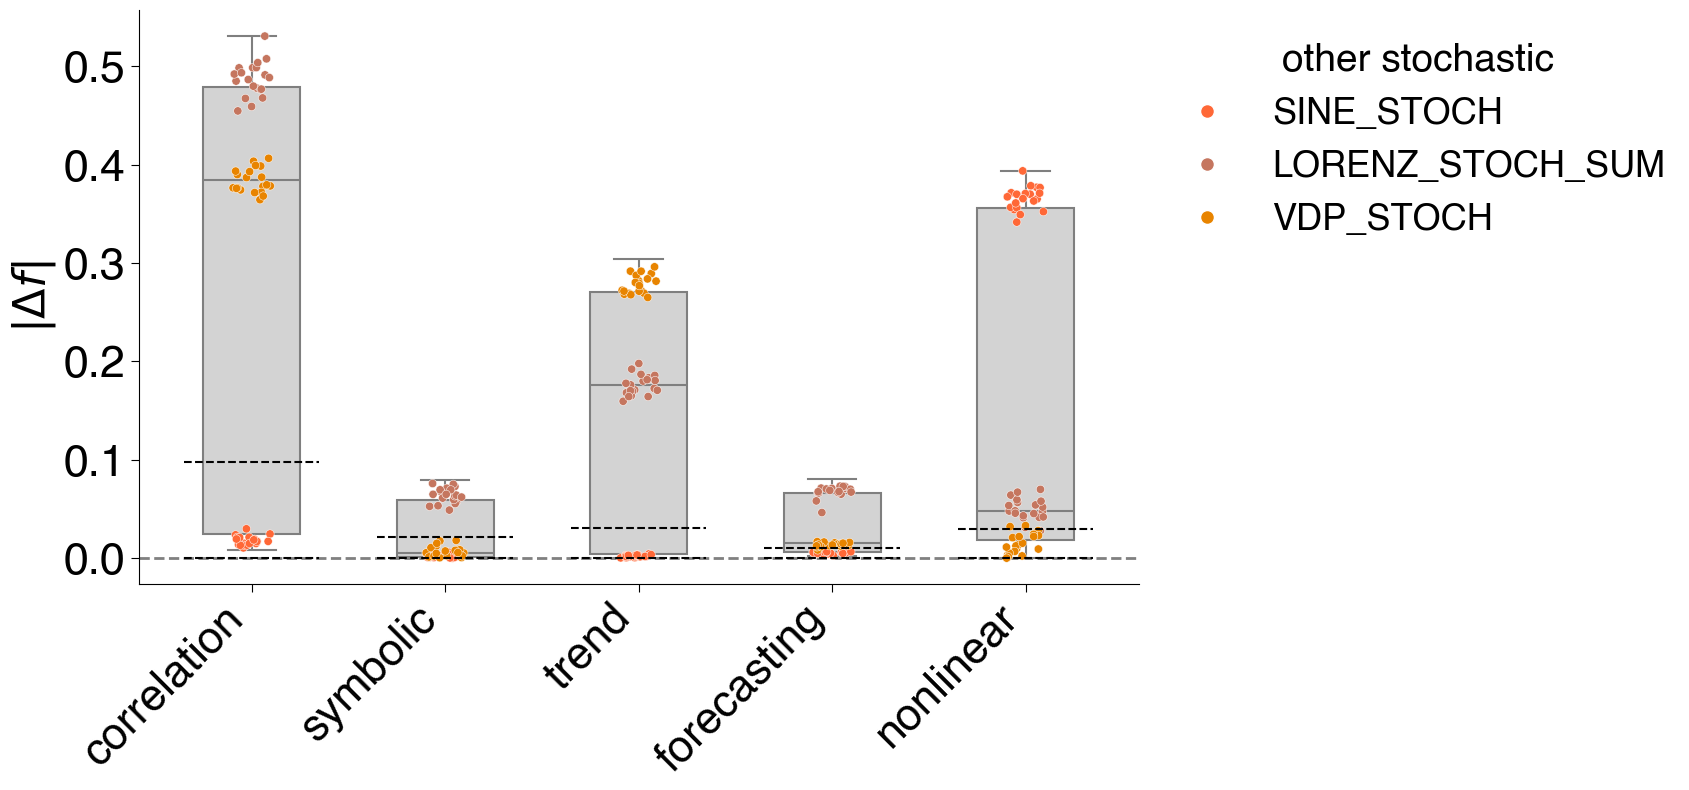

In [99]:
op1 = 'AC_nl_001' # correlation
op2 = 'SB_MotifTwo_diff_uu' # symbolic
op3 = 'PH_Walker_biasprop_01_05_w_mean' # trend
op4 = 'MF_steps_ahead_ar_2_6_mabserr_1' # forecasting
op5 = 'NL_MS_fnn_1_10_mi_5_1_max1stepchange' # nonlinear

category = 'other stochastic'

plot_single_category_box_irrev(df_good_hctsa, op1, op2, op3, op4, op5, category)

# Box plot for 2 processes to depict

In [ ]:
# Select the operation
op = 'SB_MotifTwo_diff_uu' # symbolic

# Select models
mods = ['GNO', 'HEN']
# Filter the DataFrame for the selected models
df_mods = df_good_hctsa[df_good_hctsa.index.get_level_values(0).isin(mods)]
# Absolute value of the operation
df_mods[op] = df_mods[op].abs()


/var/folders/wz/jq7_490s6t1dh9vzst6cqgdc0000gp/T/ipykernel_63558/314330569.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



/var/folders/wz/jq7_490s6t1dh9vzst6cqgdc0000gp/T/ipykernel_63558/3003548337.py:22: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



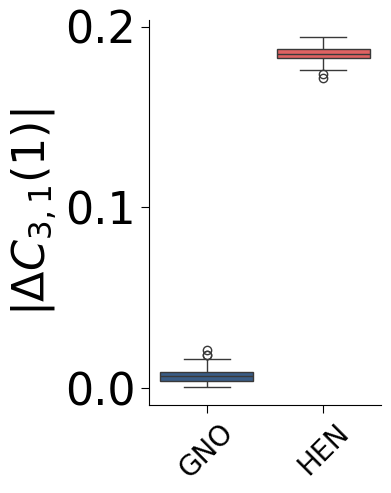

In [304]:
plt.figure(figsize=(3, 5))
palette = ['#2c5b93', '#f44d4d']
ax = sns.boxplot(x="Model", y=op, data=df_mods, hue="Type", dodge=False,
                    palette=palette)
xlim = ax.get_xlim()
ylim = ax.get_ylim()
for violin in ax.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width / 2, height, transform=ax.transData))

#sns.boxplot(x="Type", y="AC_1", data=df_hctsa_AC_sorted, saturation=1, showfliers=False,
#            width=0.3, boxprops={'zorder': 0, 'facecolor': 'none'}, ax=ax)
old_len_collections = len(ax.collections)
#sns.stripplot(x="Model", y=op, data=df_mods, hue="Type", palette=['lightgrey','lightgrey', 'lightgrey'], dodge=False, ax=ax, alpha=0.4, linewidth=0.5, edgecolor='white')
for dots in ax.collections[old_len_collections:]:
    dots.set_offsets(dots.get_offsets() + np.array([0.2, 0]))
ax.set_xlim(xlim)
ax.set_xlabel('')
ax.set_ylabel(r'$|\Delta C_{3,1}(1)|$')
ax.set_ylim(ylim)
ax.set_xticklabels(mods, fontsize=20)
# Set off legend
handles, labels = ax.get_legend_handles_labels()
if len(handles) > 0:
    ax.legend_.remove()
# Set legend with color classes
# rotate x-ticks
plt.xticks(rotation=45)
plt.show()